# 握力事件：使劲、放松与阈值区间

## tl;dr

本 Notebook 不使用 `GamePhase`、Collision 或 Trial 状态生成事件。事件完全来自未经滤波的原始握力：连续落在整段握力 mean ± 1σ 内的区间生成 `hold_in_range`，原始握力的谷→峰生成 `exertion`，峰→谷生成 `relaxation`，并按照使劲幅度分为 small / medium / large。图中只显示原始握力和这些标签，不显示 EEG。

## Context & Methods

### Key Assumptions

- 任务文件第一个信号通道是握力。
- 当前不对握力做低通或其他平滑；事件检测和阈值判断都直接使用原始握力。
- `hold_in_range` 的上下界由当前整段原始握力的 mean ± 1σ 自动生成。
- `MIN_FORCE_CHANGE` 控制忽略多小的反转；阈值越小，事件越碎。
- 默认等级边界由所有使劲幅度的三分位数得到；也可改成固定边界。
- EEG 文件仅用于通过 `SourceTime` 保存未来可用的 EEG 对齐采样点，本 Notebook 不绘制 EEG。

In [27]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display
from scipy import signal

from align_flight_eeg import align_force_to_eeg, map_task_samples_to_eeg
from read_bci2000 import BCI2000Dat

# ==================== Data ====================
DATA_DIR = Path(r"/Users/heting/Documents/20260817_HHFU202")
RUN_NAME = "testS001R14"
# ================= Force events ===============
MIN_RANGE_DURATION_S = 0.25
MIN_FORCE_CHANGE = 0.05
MIN_CHANGE_DURATION_S = 0.20
AMPLITUDE_GRADE_EDGES = None
# Fixed example: AMPLITUDE_GRADE_EDGES = (0.08, 0.13)
# ==============================================


## Data

### 1. Read paired files

读取数据单独放在对齐之前。这里不读取任何范式状态作为事件标签。

In [28]:
def find_run_pairs(data_dir):
    pairs = []
    for task_path in sorted(data_dir.rglob("*_1.dat")):
        run_name = task_path.name[:-6]
        eeg_path = task_path.with_name(f"{run_name}.dat")
        if eeg_path.exists():
            pairs.append((run_name, eeg_path, task_path))
    return pairs

data_dir = DATA_DIR.expanduser().resolve()
if not data_dir.exists():
    raise FileNotFoundError(f"数据目录不存在：{data_dir}")
run_pairs = find_run_pairs(data_dir)
available_runs = [name for name, _, _ in run_pairs]
selected = [pair for pair in run_pairs if pair[0] == RUN_NAME]
if len(selected) != 1:
    raise FileNotFoundError(
        f"Run {RUN_NAME!r} 应恰好匹配一次；可用 Run：{available_runs}"
    )
_, eeg_path, task_path = selected[0]
eeg = BCI2000Dat(eeg_path)
task = BCI2000Dat(task_path)
if "SourceTime" not in eeg.state_definitions or "SourceTime" not in task.state_definitions:
    raise ValueError("EEG 与任务文件都必须包含 SourceTime。")
task_force_raw = np.asarray(task.signals[:, 0], dtype=float)
task_time_s = np.arange(task.samples) / task.sampling_rate

print("可用 Run：", available_runs)
print("当前 Run：", RUN_NAME)
print("EEG 文件：", eeg_path)
print("任务文件：", task_path)
print(f"握力：{task.samples} samples, {task.sampling_rate:g} Hz, "
      f"{task.samples / task.sampling_rate:.3f} s")
display(pd.Series({
    "minimum": np.min(task_force_raw),
    "p01": np.percentile(task_force_raw, 1),
    "median": np.median(task_force_raw),
    "p99": np.percentile(task_force_raw, 99),
    "maximum": np.max(task_force_raw),
}, name="force").to_frame())

可用 Run： ['testS001R13', 'testS001R14', 'testS001R15', 'testS001R16', 'testS001R16a']
当前 Run： testS001R14
EEG 文件： /Users/heting/Documents/20260817_HHFU202/testS001R14.dat
任务文件： /Users/heting/Documents/20260817_HHFU202/testS001R14_1.dat
握力：122912 samples, 256 Hz, 480.125 s


,force
minimum,0.748
p01,0.767
median,0.919
p99,1.065
maximum,1.222


### 2. Inspect raw force distribution

这里在时间对齐之前检查未经滤波的原始握力分布。竖线标出 mean、median，以及 mean ± 1σ、±2σ、±3σ；σ 是整段原始握力的总体标准差，不是脑电 Theta 频带。

,raw_force
mean,0.918822
median,0.919000
sigma,0.057406
mean - 3 sigma,0.746604
mean - 2 sigma,0.804010
mean - 1 sigma,0.861416
mean + 1 sigma,0.976228
mean + 2 sigma,1.033634
mean + 3 sigma,1.091039


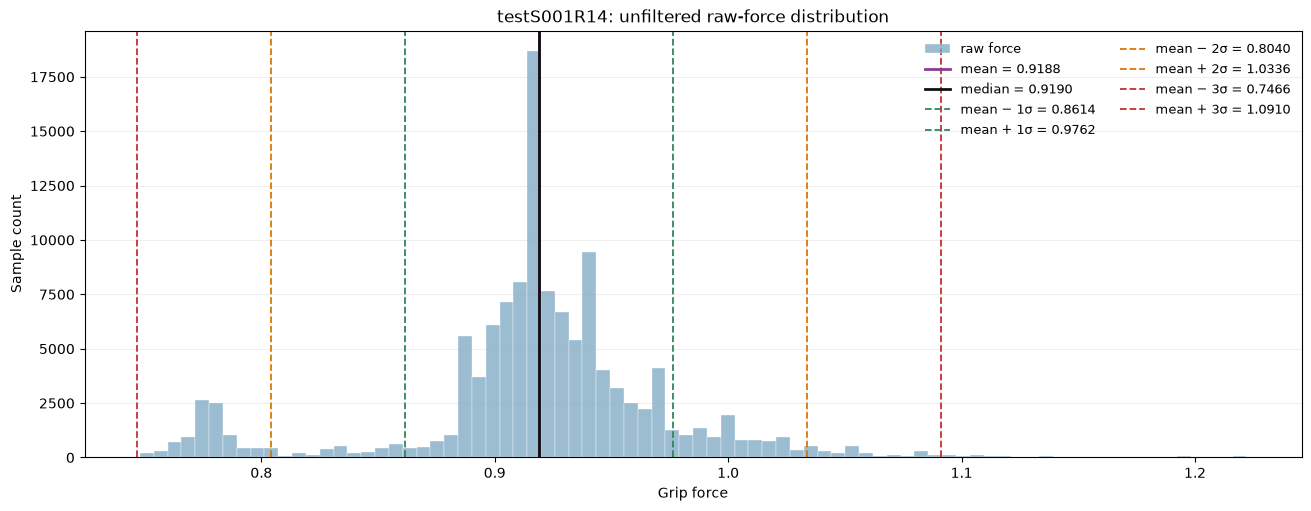

In [29]:
force_mean = float(np.mean(task_force_raw))
force_median = float(np.median(task_force_raw))
force_sigma = float(np.std(task_force_raw, ddof=0))
FORCE_RANGE = (force_mean - force_sigma, force_mean + force_sigma)

force_distribution_summary = pd.Series({
    "mean": force_mean,
    "median": force_median,
    "sigma": force_sigma,
    "mean - 3 sigma": force_mean - 3 * force_sigma,
    "mean - 2 sigma": force_mean - 2 * force_sigma,
    "mean - 1 sigma": force_mean - force_sigma,
    "mean + 1 sigma": force_mean + force_sigma,
    "mean + 2 sigma": force_mean + 2 * force_sigma,
    "mean + 3 sigma": force_mean + 3 * force_sigma,
}, name="raw_force").to_frame()
display(force_distribution_summary)

fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
ax.hist(
    task_force_raw, bins=80, color="#7AA6C2", alpha=0.75,
    edgecolor="white", linewidth=0.35, label="raw force",
)
ax.axvline(force_mean, color="#8C3B8F", lw=2.0, label=f"mean = {force_mean:.4f}")
ax.axvline(force_median, color="#111111", lw=2.0, label=f"median = {force_median:.4f}")
sigma_colors = {1: "#2F855A", 2: "#D97706", 3: "#C53030"}
for multiple in (1, 2, 3):
    color = sigma_colors[multiple]
    for sign, side in ((-1, "−"), (1, "+")):
        value = force_mean + sign * multiple * force_sigma
        ax.axvline(
            value, color=color, lw=1.3, ls="--",
            label=f"mean {side} {multiple}σ = {value:.4f}",
        )
ax.set(
    title=f"{RUN_NAME}: unfiltered raw-force distribution",
    xlabel="Grip force", ylabel="Sample count",
)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, fontsize=9, ncol=2)
display(fig)
plt.close(fig)

### 3. Align clocks

握力事件先在任务端原生 256 Hz 网格上检测，再用两端共同的 `SourceTime` 映射到 EEG 采样点。

In [30]:
eeg_clock_ms, task_clock_ms, force_at_eeg_rate = align_force_to_eeg(eeg, task)
print(
    "EEG grid with aligned force:",
    int(np.isfinite(force_at_eeg_rate).sum()), "/", eeg.samples,
)

EEG grid with aligned force: 960024 / 969600


## Results

### 4. Extract force-only labels

`force_range_events` 保存落在自定义范围内的连续片段及片段平均握力；`force_change_events` 保存使劲/放松的起止、幅度和等级；`events` 是二者合并并对齐到 EEG 后的总表。

In [31]:
def alternating_extrema(values, prominence, distance):
    peaks, _ = signal.find_peaks(
        values, prominence=prominence, distance=distance
    )
    troughs, _ = signal.find_peaks(
        -values, prominence=prominence, distance=distance
    )
    candidates = sorted(
        [(int(index), "peak") for index in peaks]
        + [(int(index), "trough") for index in troughs]
    )
    extrema = []
    for index, kind in candidates:
        if not extrema or extrema[-1][1] != kind:
            extrema.append((index, kind))
            continue
        previous_index, _ = extrema[-1]
        more_extreme = (
            values[index] > values[previous_index]
            if kind == "peak"
            else values[index] < values[previous_index]
        )
        if more_extreme:
            extrema[-1] = (index, kind)
    return extrema

if not FORCE_RANGE[0] < FORCE_RANGE[1]:
    raise ValueError("FORCE_RANGE must contain increasing bounds.")
if MIN_FORCE_CHANGE <= 0 or MIN_CHANGE_DURATION_S <= 0:
    raise ValueError("Change thresholds must be positive.")

minimum_change_samples = max(
    1, int(round(MIN_CHANGE_DURATION_S * task.sampling_rate))
)
extrema = alternating_extrema(
    task_force_raw, MIN_FORCE_CHANGE, minimum_change_samples
)

change_rows = []
for (start, _), (stop, _) in zip(extrema[:-1], extrema[1:]):
    delta = float(task_force_raw[stop] - task_force_raw[start])
    duration_s = (stop - start) / task.sampling_rate
    if abs(delta) < MIN_FORCE_CHANGE or duration_s < MIN_CHANGE_DURATION_S:
        continue
    action = "exertion" if delta > 0 else "relaxation"
    change_rows.append({
        "event": "force_rise" if delta > 0 else "force_fall",
        "action": action,
        "task_sample": int(start),
        "task_stop_sample": int(stop),
        "task_time_s": start / task.sampling_rate,
        "task_stop_time_s": stop / task.sampling_rate,
        "duration_s": duration_s,
        "start_force": float(task_force_raw[start]),
        "end_force": float(task_force_raw[stop]),
        "delta_force": delta,
        "amplitude": abs(delta),
        "mean_force": float(np.mean(task_force_raw[start:stop + 1])),
    })
force_change_events = pd.DataFrame(change_rows)
if force_change_events.empty:
    raise ValueError("No force changes met the current thresholds.")

exertion_amplitudes = force_change_events.loc[
    force_change_events.action == "exertion", "amplitude"
].to_numpy()
if AMPLITUDE_GRADE_EDGES is None:
    grade_edges = tuple(np.quantile(exertion_amplitudes, [1 / 3, 2 / 3]))
    grade_source = "exertion amplitude tertiles"
else:
    grade_edges = tuple(float(value) for value in AMPLITUDE_GRADE_EDGES)
    grade_source = "fixed user thresholds"
if len(grade_edges) != 2 or not grade_edges[0] < grade_edges[1]:
    raise ValueError("AMPLITUDE_GRADE_EDGES must be two increasing values.")
force_change_events["grade"] = pd.cut(
    force_change_events.amplitude,
    [-np.inf, grade_edges[0], grade_edges[1], np.inf],
    labels=["small", "medium", "large"],
).astype(str)
force_change_events["label"] = (
    force_change_events.action + "_" + force_change_events.grade
)

in_range = (task_force_raw >= FORCE_RANGE[0]) & (
    task_force_raw <= FORCE_RANGE[1]
)
range_edges = np.diff(np.r_[False, in_range, False].astype(np.int8))
range_starts = np.flatnonzero(range_edges == 1)
range_stops = np.flatnonzero(range_edges == -1)
minimum_range_samples = max(
    1, int(round(MIN_RANGE_DURATION_S * task.sampling_rate))
)
range_rows = []
for start, stop in zip(range_starts, range_stops):
    if stop - start < minimum_range_samples:
        continue
    values = task_force_raw[start:stop]
    range_rows.append({
        "event": "force_range", "action": "hold",
        "grade": "in_range", "label": "hold_in_range",
        "task_sample": int(start),
        "task_stop_sample": int(stop - 1),
        "task_time_s": start / task.sampling_rate,
        "task_stop_time_s": (stop - 1) / task.sampling_rate,
        "duration_s": (stop - start) / task.sampling_rate,
        "start_force": float(values[0]),
        "end_force": float(values[-1]),
        "delta_force": float(values[-1] - values[0]),
        "amplitude": float(np.ptp(values)),
        "mean_force": float(np.mean(values)),
    })
force_range_events = pd.DataFrame(range_rows)
events = pd.concat(
    [force_change_events, force_range_events], ignore_index=True
).sort_values(["task_sample", "event"]).reset_index(drop=True)

mapped_starts = map_task_samples_to_eeg(
    events.task_sample.to_numpy(dtype=int), eeg_clock_ms, task_clock_ms
)
mapped_stops = map_task_samples_to_eeg(
    events.task_stop_sample.to_numpy(dtype=int), eeg_clock_ms, task_clock_ms
)
events.insert(0, "event_id", [
    f"force-{index:04d}" for index in range(1, len(events) + 1)
])
events["eeg_sample"] = mapped_starts
events["eeg_stop_sample"] = mapped_stops
events["eeg_time_s"] = mapped_starts / eeg.sampling_rate
events["eeg_stop_time_s"] = mapped_stops / eeg.sampling_rate
events["alignment_error_ms"] = (
    eeg_clock_ms[mapped_starts]
    - task_clock_ms[events.task_sample.to_numpy(dtype=int)]
)

event_summary = (
    events.groupby(["event", "label"], observed=True)
    .agg(
        count=("event_id", "size"),
        median_amplitude=("amplitude", "median"),
        median_duration_s=("duration_s", "median"),
        mean_force=("mean_force", "mean"),
    )
    .reset_index()
)
print("Amplitude grade edges:", grade_edges, f"({grade_source})")
display(event_summary)
display(events.head(20))

Amplitude grade edges: (np.float64(0.07833333810170491), np.float64(0.13200000921885172)) (exertion amplitude tertiles)


,event,label,count,median_amplitude,median_duration_s,mean_force
0,force_fall,relaxation_large,50,0.2100,1.59375,0.926301
1,force_fall,relaxation_medium,45,0.1070,1.75000,0.931063
2,force_fall,relaxation_small,48,0.0640,1.18750,0.926667
3,force_range,hold_in_range,106,0.0780,1.87500,0.924673
4,force_rise,exertion_large,48,0.2125,0.75000,0.913941
5,force_rise,exertion_medium,47,0.0980,1.00000,0.928466
6,force_rise,exertion_small,48,0.0680,0.87500,0.925468


,event_id,event,action,task_sample,task_stop_sample,task_time_s,task_stop_time_s,duration_s,start_force,end_force,delta_force,amplitude,mean_force,grade,label,eeg_sample,eeg_stop_sample,eeg_time_s,eeg_stop_time_s,alignment_error_ms
0,force-0001,force_range,hold,736,799,2.875000,3.121094,0.2500,0.865,0.963,0.098,0.098,0.914000,in_range,hold_in_range,5899,6384,2.9495,3.1920,0.00500
1,force-0002,force_range,hold,864,927,3.375000,3.621094,0.2500,0.948,0.948,0.000,0.000,0.948000,in_range,hold_in_range,6897,7384,3.4485,3.6920,0.01500
2,force-0003,force_rise,exertion,895,1103,3.496094,4.308594,0.8125,0.948,1.085,0.137,0.137,1.022335,large,exertion_large,7138,8764,3.5690,4.3820,0.00750
3,force-0004,force_fall,relaxation,1103,1551,4.308594,6.058594,1.7500,1.085,0.762,-0.323,0.323,0.974283,large,relaxation_large,8764,12259,4.3820,6.1295,0.22625
4,force-0005,force_range,hold,1376,1439,5.375000,5.621094,0.2500,0.953,0.953,0.000,0.000,0.953000,in_range,hold_in_range,10894,11383,5.4470,5.6915,0.00000
5,force-0006,force_rise,exertion,1551,1903,6.058594,7.433594,1.3750,0.762,1.080,0.318,0.318,0.828538,large,exertion_large,12259,15011,6.1295,7.5055,-0.03500
6,force-0007,force_fall,relaxation,1903,2383,7.433594,9.308594,1.8750,1.080,0.899,-0.181,0.181,0.947376,large,relaxation_large,15011,18762,7.5055,9.3810,-0.09375
7,force-0008,force_range,hold,2016,3615,7.875000,14.121094,6.2500,0.958,0.968,0.010,0.088,0.917840,in_range,hold_in_range,15893,28388,7.9465,14.1940,0.10500
8,force-0009,force_rise,exertion,2383,2479,9.308594,9.683594,0.3750,0.899,0.953,0.054,0.054,0.922753,small,exertion_small,18762,19510,9.3810,9.7550,-0.21375
9,force-0010,force_fall,relaxation,2479,2543,9.683594,9.933594,0.2500,0.953,0.880,-0.073,0.073,0.923215,small,relaxation_small,19510,20006,9.7550,10.0030,-0.04375


In [32]:
assert set(events.event) <= {"force_rise", "force_fall", "force_range"}
assert (force_change_events.amplitude >= MIN_FORCE_CHANGE).all()
assert (force_change_events.duration_s >= MIN_CHANGE_DURATION_S).all()
assert force_range_events.mean_force.between(*FORCE_RANGE).all()
assert events.alignment_error_ms.abs().max() < 0.5
print("Force-only event checks passed.")

Force-only event checks passed.


### 5. Plot force and generated labels

上图只显示未经滤波的原始握力、紫色 mean 横线和 mean ± 1σ 蓝色范围；下图显示直接由原始握力生成的事件持续区间。绿色为使劲，红色为放松，蓝色为 `hold_in_range`。时间支持范围和固定 1 秒滑窗两种模式。

In [33]:
LABEL_ORDER = [
    "relaxation_large", "relaxation_medium", "relaxation_small",
    "hold_in_range",
    "exertion_small", "exertion_medium", "exertion_large",
]
LABEL_COLORS = {
    "exertion_small": "#A7D8A7",
    "exertion_medium": "#4FAF67",
    "exertion_large": "#176B35",
    "relaxation_small": "#F3B2AD",
    "relaxation_medium": "#D8645B",
    "relaxation_large": "#8F211B",
    "hold_in_range": "#4C78A8",
}
recording_duration_s = task.samples / task.sampling_rate

def plot_force_labels(time_mode, time_range, window_index):
    if time_mode == "window":
        start_s = float(window_index)
        stop_s = min(start_s + 1.0, recording_duration_s)
    else:
        start_s, stop_s = time_range
    if stop_s <= start_s:
        print("结束时间必须晚于开始时间。")
        return
    start_sample = max(0, int(np.floor(start_s * task.sampling_rate)))
    stop_sample = min(task.samples, int(np.ceil(stop_s * task.sampling_rate)))
    plot_step = 1  # show every original force sample; no display decimation
    indices = np.arange(start_sample, stop_sample, plot_step)
    visible_events = events.loc[
        (events.task_stop_time_s >= start_s)
        & (events.task_time_s < stop_s)
    ]

    fig, (ax_force, ax_labels) = plt.subplots(
        2, 1, figsize=(17, 8), sharex=True,
        gridspec_kw={"height_ratios": [3, 2]},
        constrained_layout=True,
    )
    ax_force.plot(
        task_time_s[indices], task_force_raw[indices],
        color="black", lw=0.8, label="raw force (unfiltered)",
    )
    ax_force.axhspan(
        FORCE_RANGE[0], FORCE_RANGE[1], color=LABEL_COLORS["hold_in_range"],
        alpha=0.12, label=f"mean ± 1σ ({FORCE_RANGE[0]:.4f}–{FORCE_RANGE[1]:.4f})",
    )
    ax_force.axhline(
        force_mean, color="#8C3B8F", lw=1.6,
        label=f"mean = {force_mean:.4f}",
    )
    for row in visible_events.itertuples():
        color = LABEL_COLORS[row.label]
        ax_force.axvspan(
            max(start_s, row.task_time_s),
            min(stop_s, row.task_stop_time_s),
            color=color, alpha=0.10,
        )
        y_index = LABEL_ORDER.index(row.label)
        left = max(start_s, row.task_time_s)
        right = min(stop_s, row.task_stop_time_s)
        ax_labels.broken_barh(
            [(left, max(0, right - left))],
            (y_index - 0.35, 0.7), facecolors=color,
        )
    ax_force.set(
        ylabel="Grip force",
        title=f"{RUN_NAME}: force-derived labels, {start_s:.1f}–{stop_s:.1f} s",
    )
    ax_force.legend(loc="upper right", frameon=False, ncol=3)
    ax_force.grid(alpha=0.2)
    ax_labels.set_yticks(np.arange(len(LABEL_ORDER)), LABEL_ORDER)
    ax_labels.set(
        xlabel="Task time (s)", ylabel="Generated label",
        ylim=(-0.7, len(LABEL_ORDER) - 0.3), xlim=(start_s, stop_s),
    )
    ax_labels.grid(axis="x", alpha=0.2)
    display(fig)
    plt.close(fig)
    print("Visible event counts:", visible_events.label.value_counts().to_dict())

time_mode_toggle = widgets.ToggleButtons(
    options=[("范围模式", "range"), ("1 秒滑窗", "window")],
    value="range", description="时间模式",
)
time_range_slider = widgets.FloatRangeSlider(
    value=(0.0, min(60.0, recording_duration_s)),
    min=0.0, max=recording_duration_s, step=0.5,
    description="时间范围 (s)", continuous_update=False,
    layout=widgets.Layout(width="95%"), readout_format=".1f",
)
max_window_index = max(0, int(np.ceil(recording_duration_s)) - 1)
window_index_slider = widgets.IntSlider(
    value=0, min=0, max=max_window_index, step=1,
    description="窗口起点 (s)", continuous_update=False,
    layout=widgets.Layout(width="82%"),
)
window_play = widgets.Play(
    value=0, min=0, max=max_window_index, step=1, interval=1000,
)
widgets.jslink((window_play, "value"), (window_index_slider, "value"))
range_box = widgets.VBox([time_range_slider])
window_box = widgets.HBox([window_play, window_index_slider])
plot_output = widgets.Output()

def update_time_visibility():
    range_box.layout.display = (
        "flex" if time_mode_toggle.value == "range" else "none"
    )
    window_box.layout.display = (
        "flex" if time_mode_toggle.value == "window" else "none"
    )

def render_force_plot(change=None):
    with plot_output:
        clear_output(wait=True)
        plot_force_labels(
            time_mode_toggle.value,
            time_range_slider.value,
            window_index_slider.value,
        )

def handle_time_mode(change=None):
    update_time_visibility()
    render_force_plot()

time_mode_toggle.observe(handle_time_mode, names="value")
time_range_slider.observe(render_force_plot, names="value")
window_index_slider.observe(render_force_plot, names="value")
update_time_visibility()
controls = widgets.VBox([
    time_mode_toggle, range_box, window_box, plot_output
])
display(controls)
render_force_plot()

## Takeaways

当前版本直接使用未经滤波的原始握力生成全部标签。请先检查原始波形及标签是否出现高频抖动、区间碎裂或伪峰谷，再决定是否需要加入滤波、去抖或稳定性约束。事件数量和幅度等级边界以本次从头执行后的输出为准。